# VARIANCE

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
import intake
from xeofs.single import EOF 
import xeofs as xe
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
#from DV8_ext_opening import *
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:


import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')
scratch_dir = Path('/scratch') / getuser()[0] / getuser()

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46707 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/46707/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/46707/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43653,Workers: 0
Dashboard: /user/b382616/levante-spawner-advanced//proxy/46707/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34551,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/40585/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:39327,


2026-01-09 13:08:51,576 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:45539 (pid=1665139) exceeded 95% memory budget. Restarting...
2026-01-09 13:08:54,720 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:45539' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-merge-2ed48b336c70bd0cbbdfce87584839d3', 33, 0, 0), ('rechunk-merge-5adf9e20f119e4e72a9c2e076180f751', 94, 0, 0), ('rechunk-merge-5adf9e20f119e4e72a9c2e076180f751', 91, 0, 0), ('getitem-0d277c692ff59871637cf888b6daa8ad', 27, 0, 0), ('rechunk-merge-2ed48b336c70bd0cbbdfce87584839d3', 95, 0, 0), ('moment_chunk-6a5cdd09cbc5072d18d85a4a357a7095', 92, 0, 0), ('rechunk-merge-2ed48b336c70bd0cbbdfce87584839d3', 94, 0, 0), ('rechunk-merge-5adf9e20f119e4e72a9c2e076180f751', 95, 0, 0), ('getitem-0d277c692ff59871637cf888b6daa8ad', 28, 0, 0)} (stimulus_id='handle-worker-cleanup-1767960534.7195735')


# LOAD DATA
### Only take latitudes between 50°S and 70°N, to retain only ice-free oceans. To make sure no sea ice appears in these latitudes we apply SSTA=SSTA.where(sst>-1.7) for all anomalies. Gridcells with sea ice are defined in OSTIA,ICON and IFS-FESOM as an SST value of ~-1.75, by applying the where condition we make sure to only take ice free times and grid-cells without throwing out entire areas, but only the times and places where sea ice appears.
### Convert ICON and IFS-FESOM longitudes from 0->360 to -180->180

In [3]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [4]:
#SST

 # OSTIA
filename='/scratch/b/b382615/mhws/ostia.zarr' 
sst = xr.open_zarr(str(filename), chunks={'time':150, 'lat':-1, 'lon':-1}).sst
sst=sst.sel(lat=slice(-50, 70))
sst=sst-273.15

# ICON HISTORICAL
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_ic = dat['2d_daily_mean'](chunks={}).to_dask().to.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_ic=sst_ic.sel(lat=slice(-50, 70))


# IFS FESOM
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.ifs-fesom2-sr.hist-1950.v20240304.ocean.gr025']#.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_f = dat['2D_daily_avg_1950-2014'].to_dask().avg_tos.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_f=sst_f.sel(lat=slice(-50, 70))



In [5]:
# HADGEM LL
sst_LL = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/LL/toscon_nemo_u-da156_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_LL=sst_LL['toscon'].sel(lat=slice(-50, 70))


# HADGEM MM
sst_MM = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/MM/toscon_nemo_u-dc396_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_MM=sst_MM['toscon'].sel(lat=slice(-50, 70))


# HADGEM HH
sst_HH = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/HH/toscon_nemo_u-di356_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_HH=sst_HH['toscon'].sel(lat=slice(-50, 70))

            

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [6]:
# SST ANOMALIES
# FIXED BASELINES


# FIXED BASELINES

# OSTIA ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
ossta=ds['dat_anomaly']
sst=sst.sel(time=slice((ossta.time[0].values),str(ossta.time[-1].values))) #making sure SST time matches SSTA time before masking the sea ice
ossta=ossta.where(sst>-1.7) #remove from anomalies places and times where there is sea ice

file_name = scratch_dir / "mhws" / "DV8"/ "OSTIA_track_1982_2014_FixedDetrend_mask70_onlyarea.zarr"
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
oblobs = ds.sel(lat=slice(-50, 70))



# ICON HIST ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
sst_ic=lon_180w_180e(sst_ic)
i_ds = i_ds.sel(lat=slice(-50, 70))
issta=i_ds['dat_anomaly']
sst_ic=sst_ic.sel(time=slice(str(issta.time[0].values),str(issta.time[-1].values)))
# Now apply the sea ice mask
issta = issta.where(sst_ic > -1.7)



# IFS-FESOM ANOMALIES
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_dec25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
sst_f=lon_180w_180e(sst_f)
f_ds = f_ds.sel(lat=slice(-50, 70))
fssta=f_ds['dat_anomaly']
sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# Now apply the sea ice mask
fssta = fssta.where(sst_f > -1.7)






# HADGEM LL ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LLssta=LL_ds['dat_anomaly']
sst_LL=sst_LL.sel(time=slice((LLssta.time[0].values),str(LLssta.time[-1].values)))
# Now apply the sea ice mask
LLssta = LLssta.where(sst_LL > -1.7)

# HADGEM MM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MMssta=MM_ds['dat_anomaly']
sst_MM=sst_MM.sel(time=slice((MMssta.time[0].values),str(MMssta.time[-1].values)))
# Now apply the sea ice mask
MMssta = MMssta.where(sst_MM > -1.7)


# HADGEM HH ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HHssta=HH_ds['dat_anomaly']
sst_HH=sst_HH.sel(time=slice((HHssta.time[0].values),str(HHssta.time[-1].values)))
# Now apply the sea ice mask
HHssta = HHssta.where(sst_HH> -1.7)



/tmp/ipykernel_1664968/1224992851.py:58: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_1664968/1224992851.py:70: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_1664968/1224992851.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


# SDV

In [7]:
models_sst = {
    'OSTIA': sst,     
    'ICON': sst_ic,      
    'IFS-FESOM': sst_f,
    'HadGEM3-HH': sst_HH
}
models_sst_lowres = {
    'HadGEM3-MM': sst_MM,
    'HadGEM3-LL': sst_LL
}

models_ssta = {
    'OSTIA': ossta,     
    'ICON': issta,     
    'IFS-FESOM': fssta,
    'HadGEM3-HH': HHssta
}

models_ssta_lowres = {
    'HadGEM3-MM': MMssta,
    'HadGEM3-LL': LLssta
}

<>:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_1664968/2496061792.py:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar_kwargs={'label': '$^\circ C$', 'shrink': 0.8})
2026-01-09 13:08:49,003 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 6.54 GiB -- Worker memory limit: 7.81 GiB
2026-01-09 13:08:51,892 - distributed.worker.memory - WARNING - Worker is at 42% memory usage. Resuming worker. Process memory: 3.36 GiB -- Worker memory limit: 7.81 GiB
2026-01-09 13:08:54,512 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.

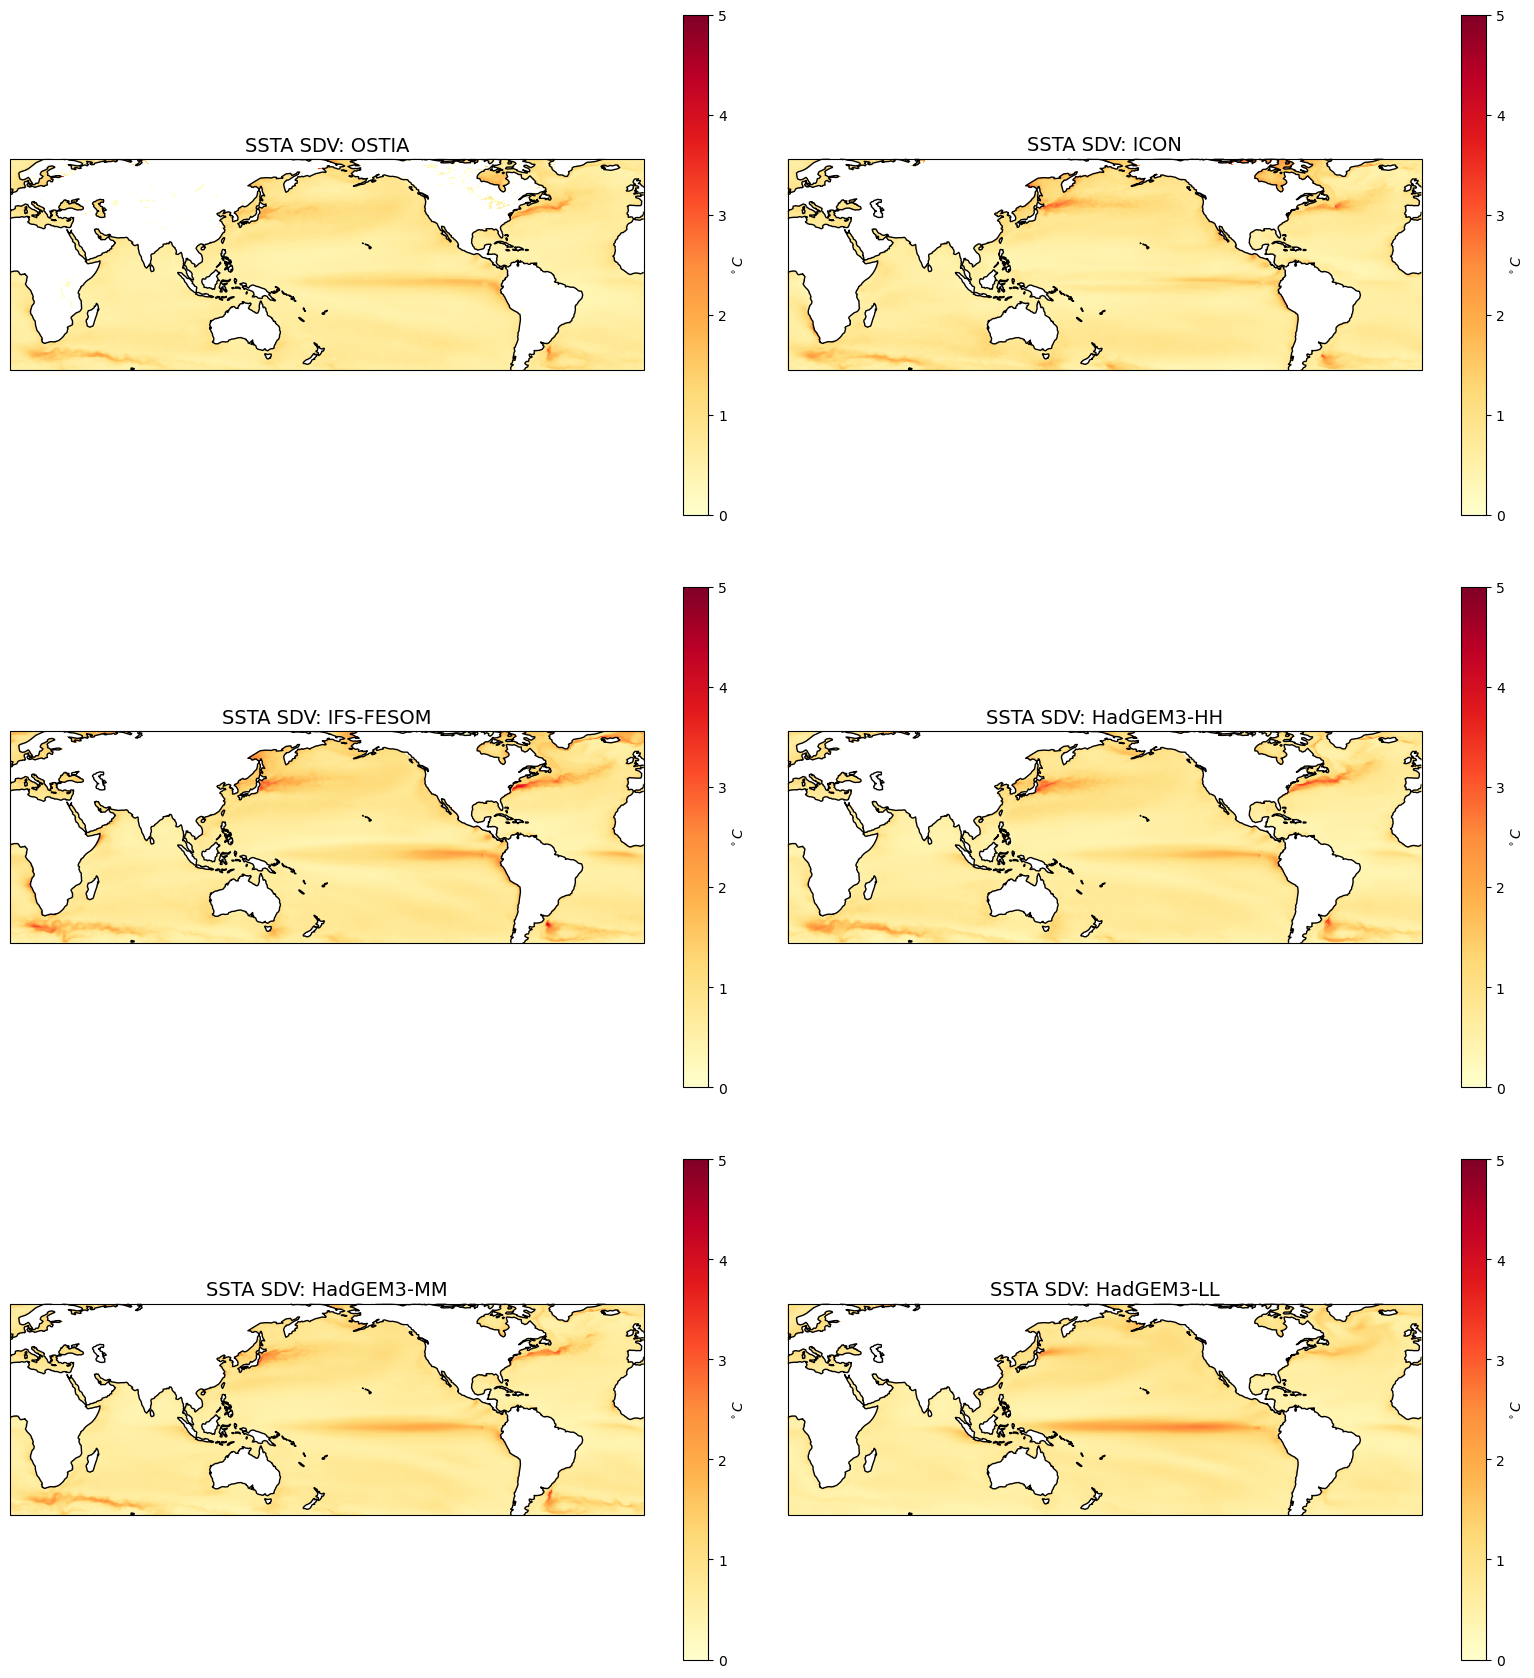

In [8]:
# SIMPLE PLOTS


# Combine high-res and low-res into one list for the loop
all_sst = {**models_ssta, **models_ssta_lowres}

fig, axes = plt.subplots(3, 2, figsize=(16, 18), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for i, (name, data) in enumerate(all_sst.items()):
    ax = axes[i]
    
    # Calculate SDV
    sdv = data.std(dim='time')
    
    # Plot
    im = sdv.plot(ax=ax, transform=ccrs.PlateCarree(), 
                  cmap='YlOrRd',vmin=0, vmax=5, robust=True, add_colorbar=True,
                  cbar_kwargs={'label': '$^\circ C$', 'shrink': 0.8})
    
    ax.coastlines()
    ax.set_title(f"SSTA SDV: {name}", fontsize=14)

plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_2952547/384662223.py:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar_kwargs={'label': '$^\circ C$', 'shrink': 0.8})
2026-01-08 14:00:23,705 - distributed.nanny - WARNING - Restarting worker
2026-01-08 14:01:04,012 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:38749
Traceback (most recent call last):
  File "/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
                     ^^^^^^^^

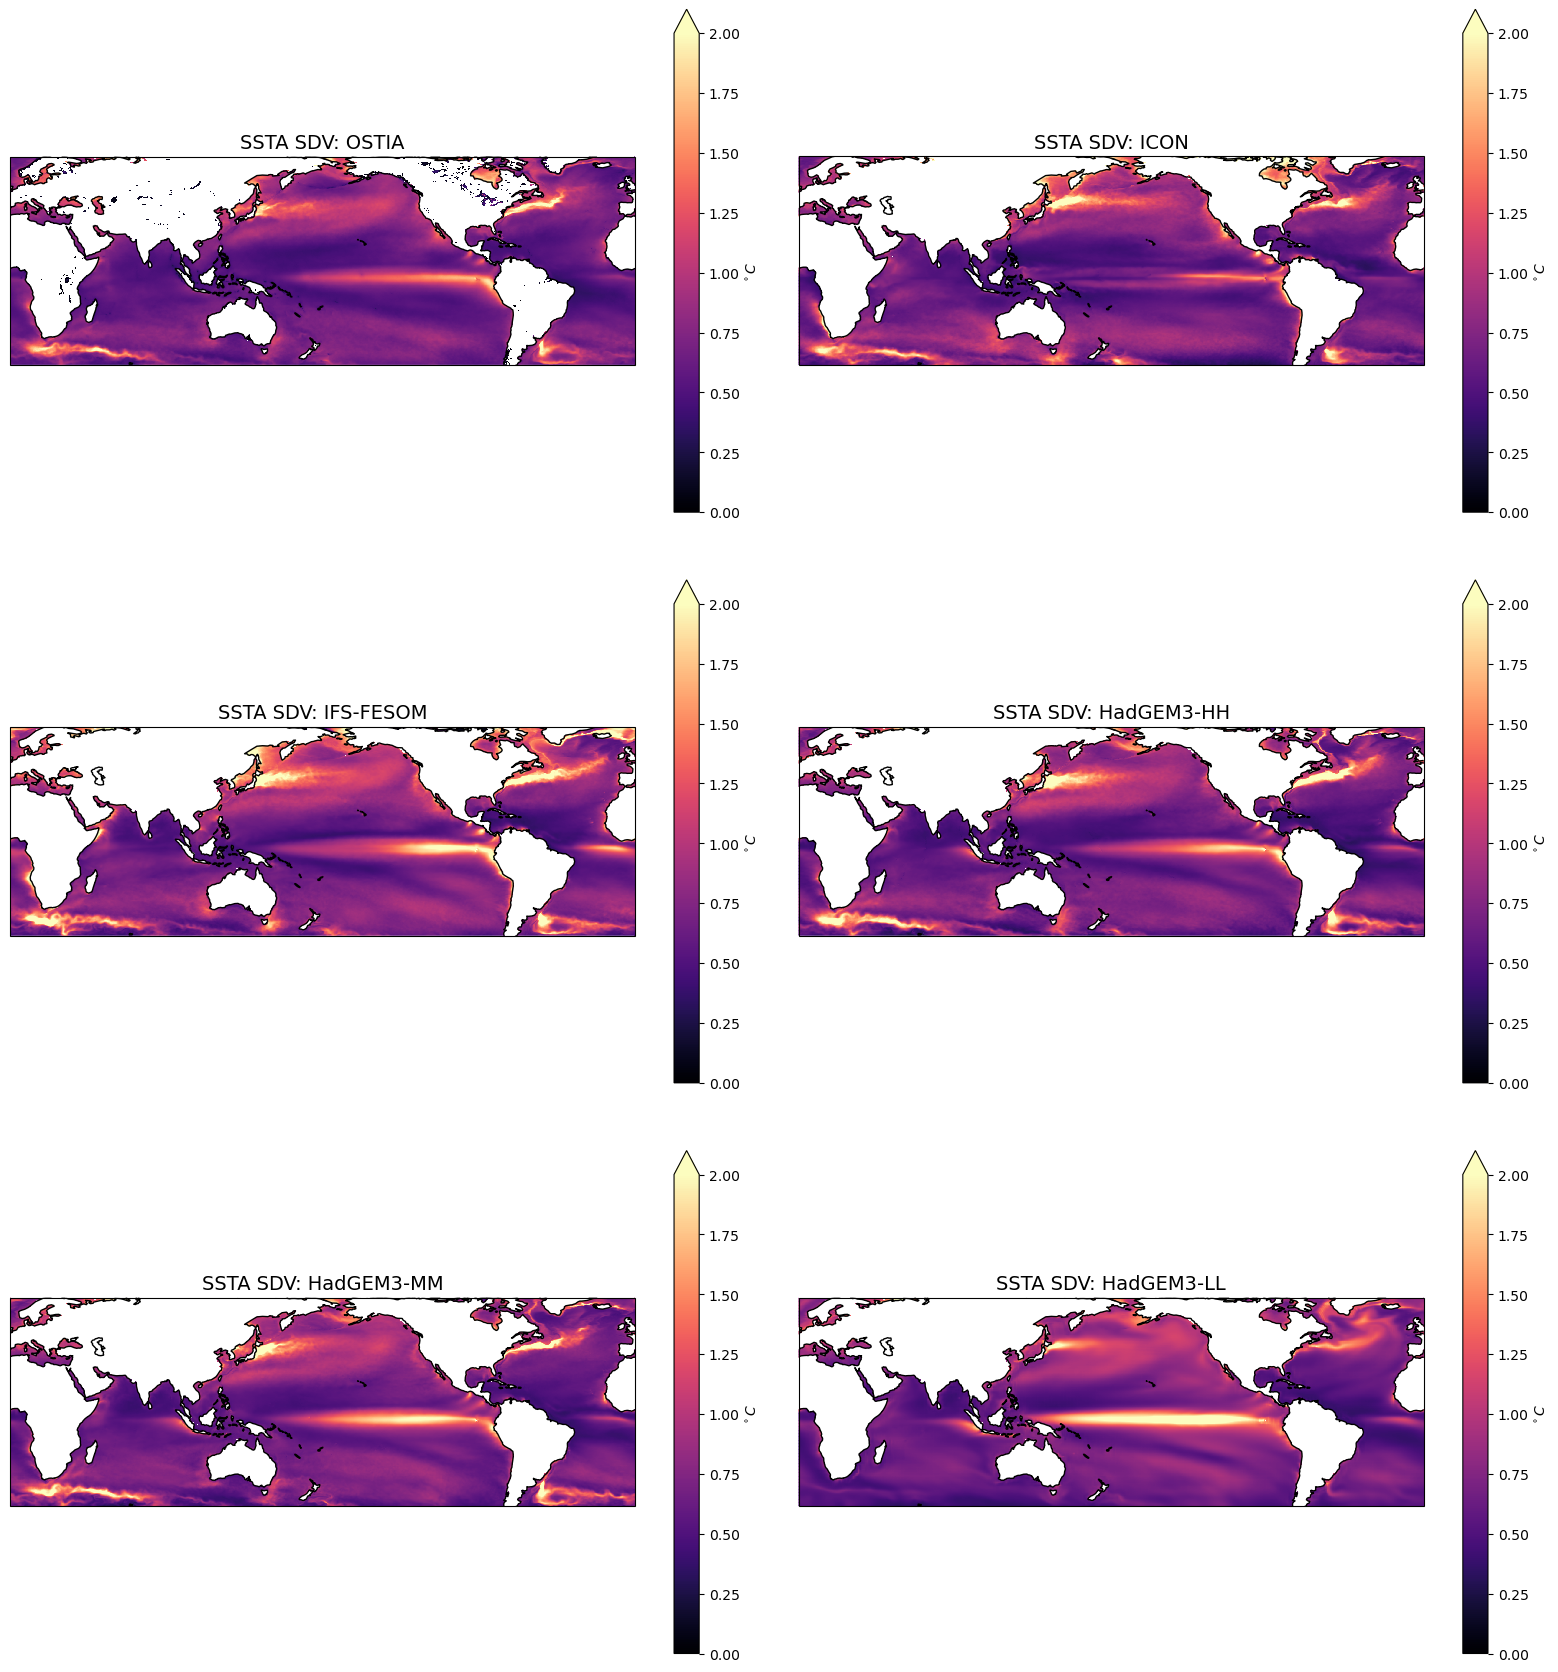

In [17]:
# Combine high-res and low-res anomalies
all_ssta = {**models_ssta, **models_ssta_lowres}

fig, axes = plt.subplots(3, 2, figsize=(16, 18), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for i, (name, data) in enumerate(all_ssta.items()):
    ax = axes[i]
    
    # Calculate SDV of anomalies
    sdv_anom = data.std(dim='time')
    
    # Plot - using a different colormap (e.g., 'magma' or 'viridis') helps distinguish it from total SST
    im = sdv_anom.plot(ax=ax, transform=ccrs.PlateCarree(), 
                       cmap='magma', robust=True,vmin=0, vmax=2, add_colorbar=True,
                       cbar_kwargs={'label': '$^\circ C$', 'shrink': 0.8})
    
    ax.coastlines()
    ax.set_title(f"SSTA SDV: {name}", fontsize=14)

plt.tight_layout()
plt.show()

# MULTI MODEL MEAN

In [8]:


# 1. Setup Reference
ref_sdv = models_sst['OSTIA'].std(dim='time')

# 2. Extract and Align High-Res Models
# (Using the list you provided for high-res: ICON, IFS-FESOM, HadGEM3-HH)
high_res_names = ['ICON', 'IFS-FESOM', 'HadGEM3-HH']
aligned_sdvs = []

for name in high_res_names:
    m_sdv = models_sst[name].std(dim='time')
    # Use nearest-neighbor interpolation to align grids
    m_sdv_aligned = m_sdv.interp_like(ref_sdv, method='nearest')
    aligned_sdvs.append(m_sdv_aligned.assign_coords(model=name))



In [9]:
# 3. Calculate Statistics
# Combine along a new 'model' dimension
combined_sdv = xr.concat(aligned_sdvs, dim='model')

mmm_sdv = combined_sdv.mean(dim='model')        # Multi-model mean
model_spread = combined_sdv.std(dim='model')    # Inter-model spread (noise)
bias = mmm_sdv - ref_sdv                        # Total Bias


In [10]:

# 4. Define Statistical Relevance
# Difference is relevant if the absolute bias is greater than the model spread
# (This is similar to a Signal-to-Noise ratio check)
relevant_mask = np.abs(bias) > model_spread


<>:9: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:9: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_2952547/1687277122.py:9: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar_kwargs={'label': 'Mean SST Standard Deviation ($^\circ C$)'}
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/da

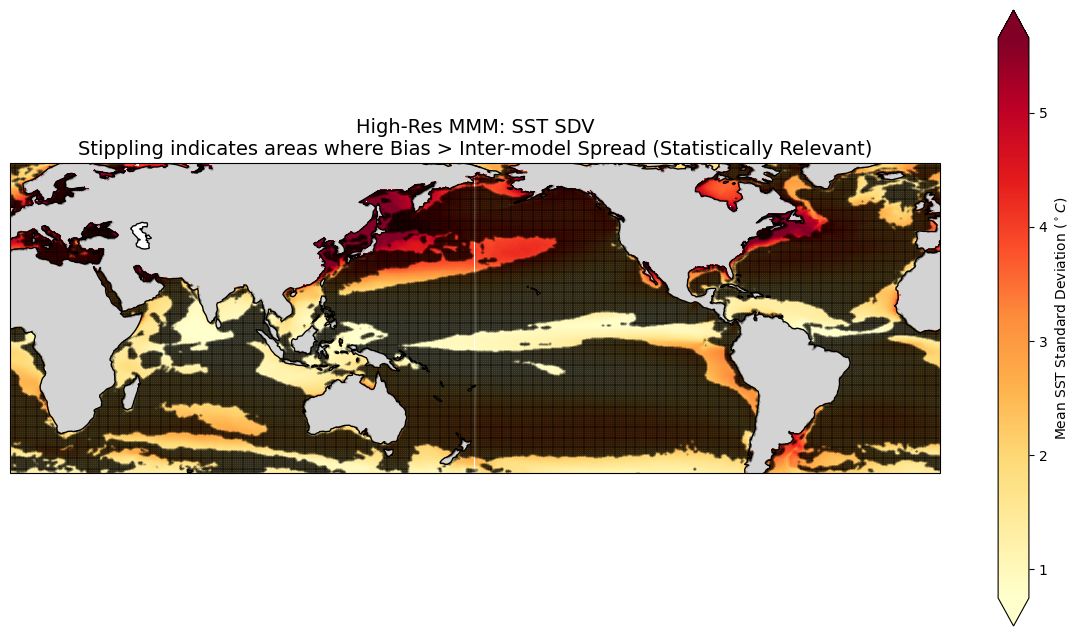

In [11]:

# 5. Plotting
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# Plot the MMM SDV as the background
im = mmm_sdv.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='YlOrRd', robust=True,
    cbar_kwargs={'label': 'Mean SST Standard Deviation ($^\circ C$)'}
)

# Overlay Stippling for Statistical Relevance
# We only plot dots where the Bias is greater than the Spread
lons, lats = np.meshgrid(mmm_sdv.lon, mmm_sdv.lat)
ax.scatter(
    lons[relevant_mask.values], lats[relevant_mask.values], 
    transform=ccrs.PlateCarree(),
    color='black', s=0.4, alpha=0.3, marker='.'
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
plt.title("High-Res MMM: SST SDV\nStippling indicates areas where Bias > Inter-model Spread (Statistically Relevant)", fontsize=14)

plt.show()

<>:13: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:13: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_2952547/533775322.py:13: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar_kwargs={'label': 'Mean SST Standard Deviation ($^\circ C$)', 'shrink': 0.8}
2026-01-08 13:16:38,900 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 6.28 GiB -- Worker memory limit: 7.81 GiB
2026-01-08 13:16:39,167 - distributed.worker.memory - WARNING - Worker is at 78% memory usage. Resuming worker. Process memory: 6.12 GiB -- Worker memory limit: 7.81 GiB
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/

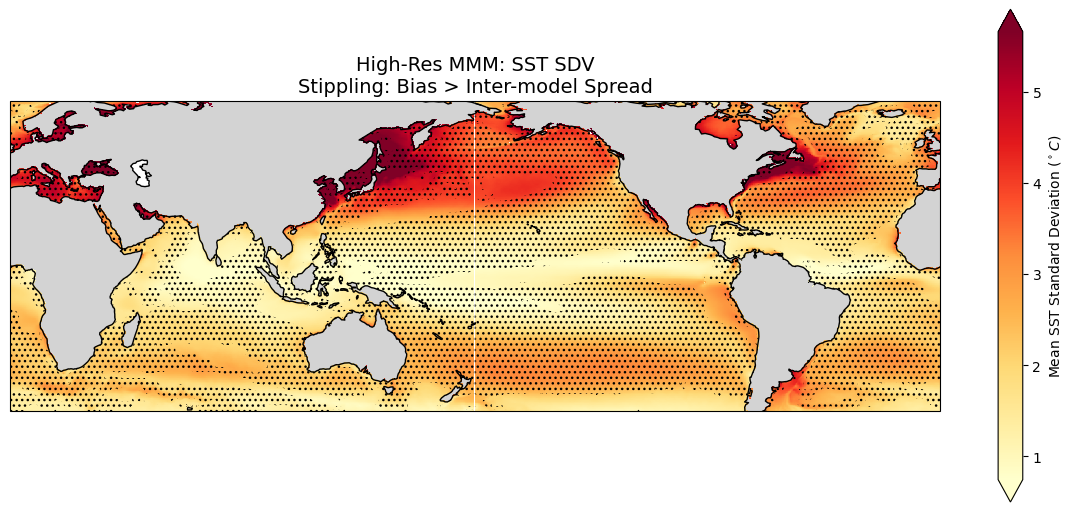

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# 1. Plot the background (Same as before, xarray .plot is usually fast)
im = mmm_sdv.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='YlOrRd', robust=True,
    add_colorbar=True,
    cbar_kwargs={'label': 'Mean SST Standard Deviation ($^\circ C$)', 'shrink': 0.8}
)

# 2. Optimized Stippling using contourf hatches
# We plot the mask where 'relevant_mask' is True. 
# [0, 0.5, 1] creates a levels boundary for the boolean mask.
ax.contourf(
    mmm_sdv.lon, mmm_sdv.lat, relevant_mask,
    transform=ccrs.PlateCarree(),
    levels=[0.5, 1.5],  # Only fill where value is 1 (True)
    hatches=['...'],    # Use dots
    colors='none',      # Don't fill with color, just the hatch
    add_colorbar=False
)

# 3. Add map details
ax.coastlines(resolution='110m') # Use coarser coastlines if still slow
ax.add_feature(cfeature.LAND, facecolor='lightgray')
plt.title("High-Res MMM: SST SDV\nStippling: Bias > Inter-model Spread", fontsize=14)

plt.show()

# VARIANCE

In [ ]:


# 1. Calculate variance (remains lazy until plotting/computing)
sst_var = sst.var(dim='time')

# 2. Create the figure and map
plt.figure(figsize=(15, 8))

# Define the display projection centered on the Pacific (180°)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# 3. Plot the data
# transform=ccrs.PlateCarree() tells Cartopy the data itself is in standard +/-180 lon
im = sst_var.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='RdYlBu_r', 
    robust=True,
    add_colorbar=True,
    cbar_kwargs={'label': 'SST Variance ($^\circ C^2$)', 'shrink': 0.8}
)

# 4. Add map details
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray') # Keeps the land clean

plt.title("SST Variance", fontsize=14)
plt.show()